# Empirical exploration of ensemble methods

### Questions
> 1. Apply sklearn DecisionTreeClassifier on the egg-yoke dataset and visualize the results with `visualize_classifier` and with sklearn plot_tree.
> 2. By following the algorithm explained [here](https://scikit-learn.org/stable/modules/tree.html#tree-algorithms), retrace the steps that led to this tree.
> 3. The egg-yoke dataset was produced with the sklearn function make_circle. The parameters noise and factor where set to produce a separable dataset. Try noise = 0 to understand how the data is generated. Generate new train and test sets with noise=0.2, factor=0.25, to make the problem more difficult. Fit a tree, visualize and compute generalization error. Generate another train set and repeat. What do you observe.
> 4. *Random forest:* Boostrap allows the simulation of several training samples, by picking n out of m examples with replacement. Bootstrap aggregating (Bagging) classifiers is an ensemble learning methods, which combines the predictors obtained by the same model over bootstraped version of the train set (see Bishop p.656). In the following experiment you will keep only one train set and the test set from the previous question. 
>     1. Using numpy randint, boostrap the train set to obtained two resampled train sets of size 3/4th that of the original dataset. Fit a tree in each resampled train set, visualize and compute generalization error. Combine the decision of both predictors and compute generalization error of the combination.
>     2. Repeat the experiment on a larger scale by using sklearn BaggingClassifier

In [41]:
import sklearn as sl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [42]:
def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()
    
    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # fit the estimator
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap=cmap, zorder=1)

    ax.set(xlim=xlim, ylim=ylim)
    ax.grid()
    return ax

# Question 1

In [43]:
data_train = pd.read_csv("eggyoke_traindata.csv")

X_train = data_train[["x_1", "x_2"]].to_numpy()
y_train = data_train["y"].to_numpy()


data_test = pd.read_csv("eggyoke_testdata.csv")

X_test = data_test[["x_1", "x_2"]].to_numpy()
y_test = data_test["y"].to_numpy()

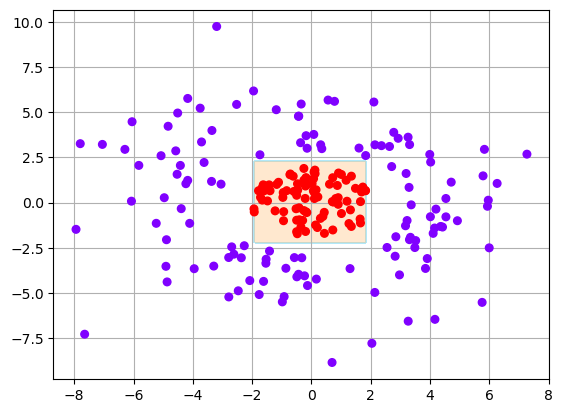

In [44]:
model = sl.tree.DecisionTreeClassifier()

ax = visualize_classifier(model, X_train, y_train)

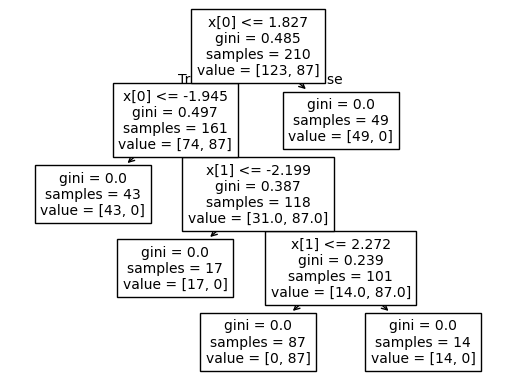

In [45]:
model.fit(X_train, y_train)

sl.tree.plot_tree(model)
plt.show()

# Question 2

## Step 1: Start

We start at the root and we put inside all the samples. Then we compute the Gini impurity of the node:
\begin{equation*}
G = 1 - \sum_k{p_k^2}
\end{equation*}

where $p_k$ is the proportion of class $k$

## Step 2: Find the optimal $\theta^*$

We need to find $\theta^* = (j,t_m)$ at the node $m$ such that the impurity is minimized:
\begin{equation*}
G(Q_m,\theta) = \frac{n_m^{left}}{n_m}H(Q_m^{left}(\theta)) + \frac{n_m^{right}}{n_m}H(Q_m^{right}(\theta))
\end{equation*}
\begin{equation*}
\theta^* = \arg\min_\theta G(Q_m,\theta)
\end{equation*}
where $H()$ is a loss function

To find the best $\theta$, the algorithm use the best splitter by performing a greedy exhaustive search over all available features $j$ and all possible thresholds $t_m$, selecting the pair that exactly minimizes $G(Q_m,\theta)$

## Step 3: Repeat the operation

When the best $\theta$ is found, we repeat recursively the same operation to each partition $Q_m^{left}(\theta^*)$ and $Q_m^{right}(\theta^*)$.

We stops the algorithm when there is no more impurity or if $n_m$ is smaller than a minimum sample split or if we reached the maximal depth.

# Question 3

In [46]:
noise = 0

X, y = sl.datasets.make_circles(noise=noise)

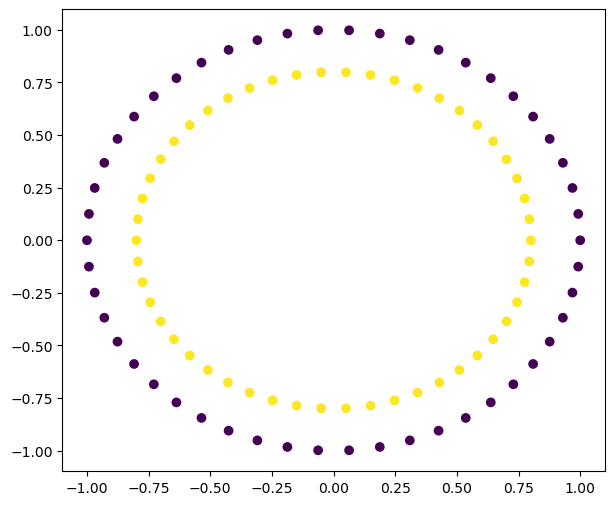

In [47]:
plt.figure(figsize=(7,6))
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [48]:
noise = 0.2
factor=0.25

X_tr, y_tr = sl.datasets.make_circles(noise=noise, factor=factor, n_samples=250)
X_te, y_te = sl.datasets.make_circles(noise=noise, factor=factor, n_samples=250)

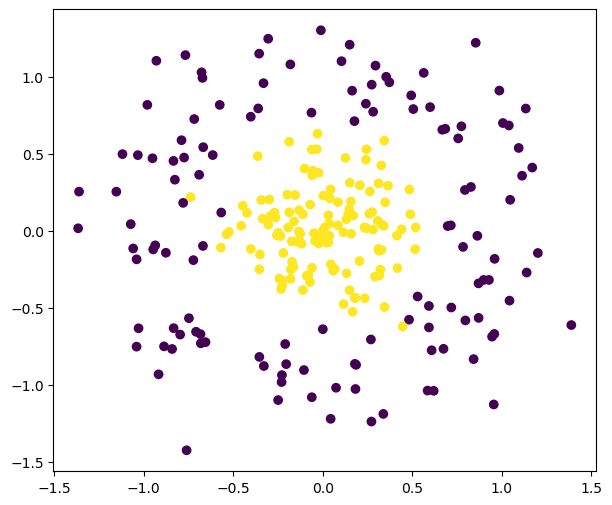

In [49]:
plt.figure(figsize=(7,6))
plt.scatter(X_tr[:,0], X_tr[:,1], c=y_tr)
plt.show()

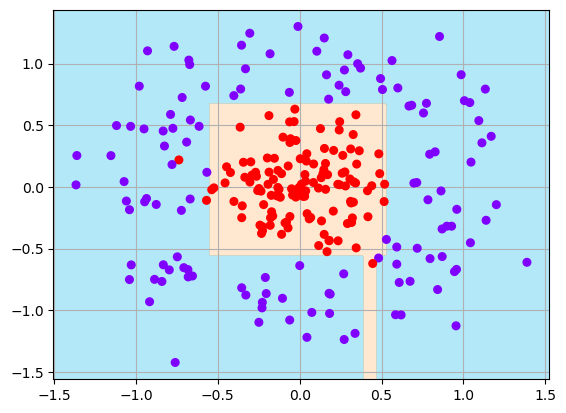

In [50]:
tree = sl.tree.DecisionTreeClassifier()

visualize_classifier(tree, X_tr, y_tr)
plt.show()

In [51]:
from sklearn.metrics import accuracy_score

y_predict_train = tree.predict(X_tr)
y_predict_test = tree.predict(X_te)

training_AC = accuracy_score(y_tr, y_predict_train)
generalization_AC = accuracy_score(y_te, y_predict_test)

print(f"The training accuracy score is {training_AC}")
print(f"The generalization accuracy score is {generalization_AC}")

The training accuracy score is 1.0
The generalization accuracy score is 0.936


In [52]:
#We test again to compare from the previous test
X_tr, y_tr = sl.datasets.make_circles(noise=noise, factor=factor, n_samples=250)
X_te, y_te = sl.datasets.make_circles(noise=noise, factor=factor, n_samples=250)

y_predict_train = tree.predict(X_tr)
y_predict_test = tree.predict(X_te)

training_AC = accuracy_score(y_tr, y_predict_train)
generalization_AC = accuracy_score(y_te, y_predict_test)

print(f"The training accuracy score is {training_AC}")
print(f"The generalization accuracy score is {generalization_AC}")

The training accuracy score is 0.964
The generalization accuracy score is 0.928


We notice  that the accuracy scores are not the same from the first computation. This is due to the creation of the dataset which remains random even whether we had the same parameters

# Question 4

## Question A

In [53]:
m = len(X_tr)

n = int(0.75*m)

# Retrieve the random index of both training samples
idx1 = np.random.randint(0,m,n)
idx2 = np.random.randint(0,m,n)

In [54]:
tree_1 = sl.tree.DecisionTreeClassifier().fit(X_tr[idx1], y_tr[idx1])

tree_2 = sl.tree.DecisionTreeClassifier().fit(X_tr[idx2], y_tr[idx2])

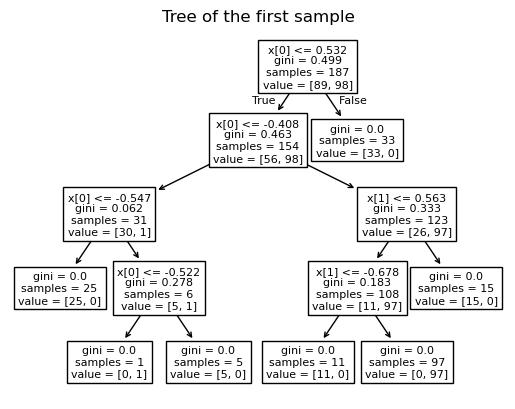

In [55]:
sl.tree.plot_tree(tree_1)
plt.title("Tree of the first sample")
plt.show()

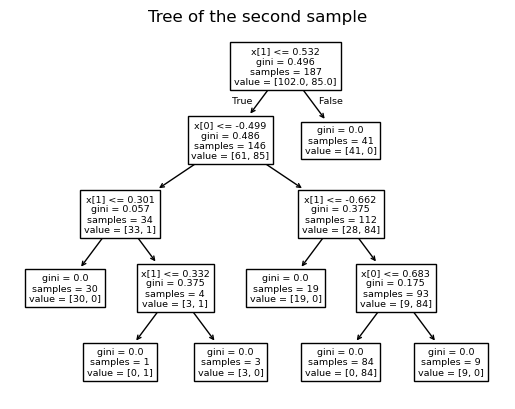

In [56]:
sl.tree.plot_tree(tree_2)
plt.title("Tree of the second sample")
plt.show()

In [57]:
# Computing the generalization error
y_pred1 = tree_1.predict(X_te[idx1])
y_pred2 = tree_2.predict(X_te[idx2])

g_error1 = accuracy_score(y_pred1, y_te[idx1])
g_error2 = accuracy_score(y_pred2, y_te[idx2])

print(f"The generalization accruracy score for the first sample is {g_error1}")
print(f"The generalization accruracy score for the second sample is {g_error2}")


The generalization accruracy score for the first sample is 0.9037433155080213
The generalization accruracy score for the second sample is 0.9251336898395722


## Question B

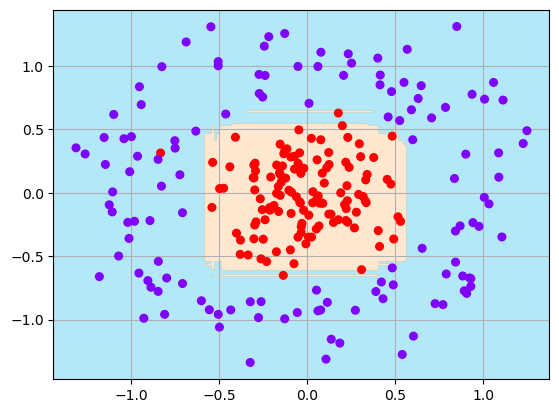

In [58]:
bc = sl.ensemble.BaggingClassifier()
bc.fit(X_tr, y_tr)

visualize_classifier(bc, X_tr, y_tr)
plt.show()

In [59]:
y_pred = bc.predict(X_te)

g_error = accuracy_score(y_pred, y_te)

print(f"The generalization accuracy score is {g_error}")

The generalization accuracy score is 0.952
